In [2]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r "/content/drive/MyDrive/kagglecatsanddogs_5340" "/content/"

Mounted at /content/drive


In [34]:
dataset_path = "/content/kagglecatsanddogs_5340/PetImages"

print(os.listdir(dataset_path))

['Dog', 'Cat']


In [35]:
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 23682 files belonging to 2 classes.
Using 18946 files for training.
Found 23682 files belonging to 2 classes.
Using 4736 files for validation.


In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [38]:
model = keras.Sequential([
    layers.Input(shape=(180,180,3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(16,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,300,641 (12.59 MB)

 Trainable params: 3,300,641 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [41]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.6329 - loss: 0.6364 - val_accuracy: 0.7057 - val_loss: 0.5663
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.7131 - loss: 0.5616 - val_accuracy: 0.7540 - val_loss: 0.4953
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.7442 - loss: 0.5201 - val_accuracy: 0.7506 - val_loss: 0.5037
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 55s 38ms/step - accuracy: 0.7595 - loss: 0.4978 - val_accuracy: 0.7872 - val_loss: 0.4579
Epoch 5/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 77s 32ms/step - accuracy: 0.7772 - loss: 0.4742 - val_accuracy: 0.7962 - val_loss: 0.4370
Epoch 6/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.7880 - loss: 0.4575 - val_accuracy: 0.8121 - val_loss: 0.4192
Epoch 7/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.7985 - loss: 0.4430 - val_accuracy: 0.8064 - val_loss: 0.4240
Epoch 8/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.8068 - loss: 0.4236 - 

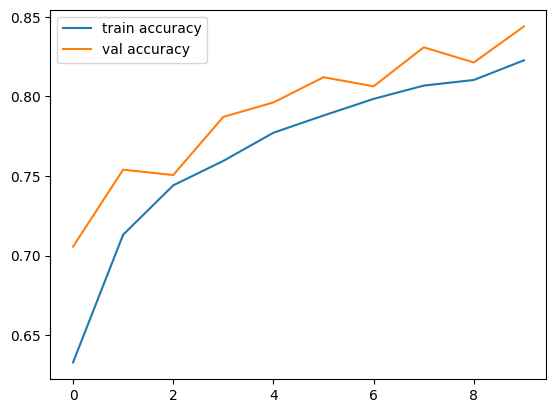

In [44]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

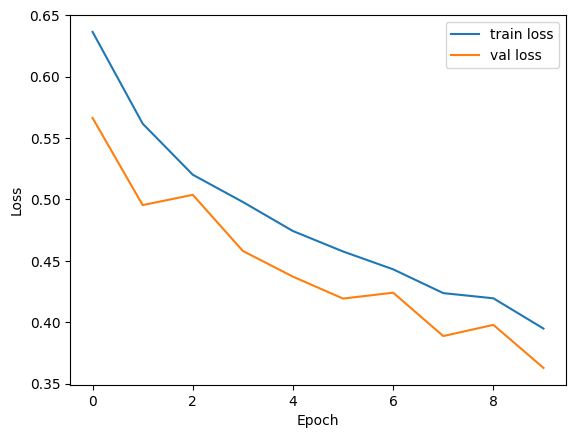

In [45]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [46]:
class_names = ['Cat', 'Dog']

In [47]:
from google.colab import files
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# 1. Upload image
uploaded = files.upload()

# 2. Get image path
img_path = list(uploaded.keys())[0]

# 3. Load + preprocess image
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)[0][0]

# 5. Output result
print("Confidence:", prediction)

if prediction > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

Saving 10000.jpg to 10000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Confidence: 0.96870327
Dog 🐶


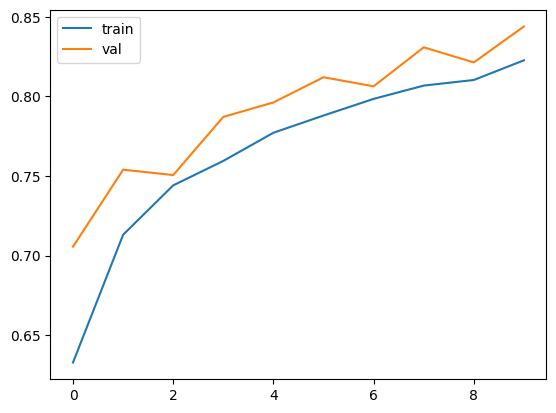

In [48]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [49]:
test_loss, test_acc = model.evaluate(val_ds, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3627
Test Accuracy: 0.8440


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━

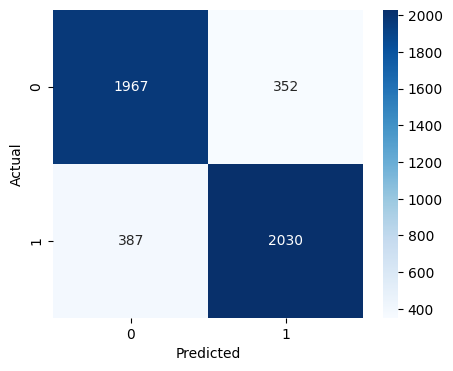

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
print(classification_report(y_true, y_pred, target_names=["Cat", "Dog"]))

              precision    recall  f1-score   support

         Cat       0.84      0.85      0.84      2319
         Dog       0.85      0.84      0.85      2417

    accuracy                           0.84      4736
   macro avg       0.84      0.84      0.84      4736
weighted avg       0.84      0.84      0.84      4736



In [52]:
model.save("cat_dog_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [53]:
new_model = tf.keras.models.load_model("cat_dog_model.h5")
print("Model loaded!")

Model loaded!


In [1]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

NameError: name 'plt' is not defined

In [55]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_image(img_path, model):
    img = load_img(img_path, target_size=(180, 180))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    print("Confidence:", pred)

    if pred > 0.5:
        print("Prediction: Dog 🐶")
    else:
        print("Prediction: Cat 🐱")

In [56]:
predict_image("9988.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Confidence: 0.7470073
Prediction: Dog 🐶


In [57]:
model.save("cat_dog_model.keras")

In [58]:
layers.Flatten(),

layers.Dense(128, activation='relu'),

layers.Dropout(0.5),

layers.Dense(1, activation='sigmoid')

<Dense name=dense_7, built=False>

In [62]:
from google.colab import files
files.download("cat_dog_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>